In [265]:
import pandas as pd
scores = pd.read_csv("results_scored.csv")
scores = scores.drop_duplicates()

In [266]:
human_seen_results = pd.read_csv("results_from_humans_scored.csv")
human_seen_results

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,For the Peace of the world,TFIDF_GLoVe,5,38.43,Bible,96,By David when His earth is restored The Lord r...,False,A,2
1,For the Peace of the world,BERT,5,99.09,Psalter,43,"We have heard with our ears, O God, for our fa...",False,B,1
2,For the Peace of the world,SBERT,5,96.16,Bible,115,Alleluia Ibelieved therefore I spoke I was gre...,False,C,0
3,The Lord is my shepherd,TFIDF_GLoVe,4,46.20,Bible,117,Alleluia Give thanks to the Lord for He is goo...,False,A,3
4,The Lord is my shepherd,BERT,4,99.41,Psalter,46,"O clap your hands, all ye nations; shout unto ...",False,B,1
...,...,...,...,...,...,...,...,...,...,...
760,"Have mercy on me, O God, have mercy on me. For...",TFIDF,1,21.90,Psalter,39,"I waited patiently for the Lord, and He inclin...",True,D,0
761,How does the psalmist express trust in God whi...,TFIDF_GLoVe,4,20.40,Psalter,61,Shall not my soul be subject unto God? for fro...,True,A,2
762,How does the psalmist express trust in God whi...,BERT,4,99.81,Bible,12,For the End a psalm by David How long O Lord W...,True,B,3
763,How does the psalmist express trust in God whi...,SBERT,4,97.27,Psalter,122,"Unto Thee have I lifted up mine eyes, O Thou t...",True,C,1


In [267]:
human_results = pd.read_csv("results_scored_human.csv")
human_results

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...
...,...,...,...,...,...,...,...
210,Verses where the psalmist remembers past deliv...,TFIDF,1,16.33,Psalter,86,His foundations are in the holy mountains. The...
211,Verses where the psalmist remembers past deliv...,TFIDF,2,9.98,Psalter,23,"The earth is the Lord's, and the fulness there..."
212,Verses where the psalmist remembers past deliv...,TFIDF,3,7.79,Bible,130,1An ode of ascents by David OLord My heart is ...
213,Verses where the psalmist remembers past deliv...,TFIDF,4,7.08,Psalter,61,Shall not my soul be subject unto God? for fro...


In [268]:
keys = ['Query', 'Method', 'Rank']

human_seen_results_clean = human_results.merge(
    human_seen_results[keys].drop_duplicates(),
    on=keys,
    how='inner'
)

print("Before:", len(human_seen_results))
print("After:", len(human_seen_results_clean))

Before: 765
After: 215


In [269]:
human_seen_results_clean

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...
...,...,...,...,...,...,...,...
210,Verses where the psalmist remembers past deliv...,TFIDF,1,16.33,Psalter,86,His foundations are in the holy mountains. The...
211,Verses where the psalmist remembers past deliv...,TFIDF,2,9.98,Psalter,23,"The earth is the Lord's, and the fulness there..."
212,Verses where the psalmist remembers past deliv...,TFIDF,3,7.79,Bible,130,1An ode of ascents by David OLord My heart is ...
213,Verses where the psalmist remembers past deliv...,TFIDF,4,7.08,Psalter,61,Shall not my soul be subject unto God? for fro...


In [270]:
keys = ['Query', 'Method', 'Rank']

# One row per result
scores_to_keep = (
    human_seen_results
    .drop_duplicates(subset=keys, keep='last')
)

# Merge scores onto the 215-row master dataset
human_results_scored = human_results.merge(
    scores_to_keep,
    on=keys,
    how='left',
    suffixes=('', '_seen')
)

print(len(human_results_scored))  # Should be 215

215


In [271]:
human_results_scored

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Similarity Score (%)_seen,Text_seen,Psalm Num_seen,Verse_seen,Scored,Letter,Score
0,Create in me a clean heart,TFIDF_GLoVe,1,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,26.10,Psalter,100,I will sing of mercy and judgment unto Thee O ...,False,A,3
1,Create in me a clean heart,TFIDF_GLoVe,2,25.67,Bible,4,For the End in psalms an ode by David You hear...,25.67,Bible,4,For the End in psalms an ode by David You hear...,True,A,0
2,Create in me a clean heart,TFIDF_GLoVe,3,21.90,Bible,31,By David concerning understanding Blessed are ...,21.90,Bible,31,By David concerning understanding Blessed are ...,True,A,3
3,Create in me a clean heart,TFIDF_GLoVe,4,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,18.33,Psalter,31,Blessed are they whose iniquities are forgiven...,True,A,3
4,Create in me a clean heart,TFIDF_GLoVe,5,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,18.12,Bible,61,For the End for Jeduthun a psalm by David Shal...,False,A,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,Verses where the psalmist remembers past deliv...,TFIDF,1,16.33,Psalter,86,His foundations are in the holy mountains. The...,16.33,Psalter,86,His foundations are in the holy mountains. The...,True,D,0
211,Verses where the psalmist remembers past deliv...,TFIDF,2,9.98,Psalter,23,"The earth is the Lord's, and the fulness there...",9.98,Psalter,23,"The earth is the Lord's, and the fulness there...",False,D,2
212,Verses where the psalmist remembers past deliv...,TFIDF,3,7.79,Bible,130,1An ode of ascents by David OLord My heart is ...,7.79,Bible,130,1An ode of ascents by David OLord My heart is ...,False,D,1
213,Verses where the psalmist remembers past deliv...,TFIDF,4,7.08,Psalter,61,Shall not my soul be subject unto God? for fro...,7.08,Psalter,61,Shall not my soul be subject unto God? for fro...,True,D,3


In [272]:
draft_scores = scores.copy()

In [273]:
# 3. Remove the old versions of these 215 results from scores
scores_without_human = (
    draft_scores
    .merge(
        human_results[keys],
        on=keys,
        how='left',
        indicator=True
    )
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
)

# 4. Add the newly scored versions
scores_updated = pd.concat(
    [scores_without_human, human_results_scored],
    ignore_index=True
)

print("Original scores:", len(draft_scores))
print("Updated scores:", len(scores_updated))
print("Rows replaced:", len(human_results_scored))

Original scores: 4841
Updated scores: 4778
Rows replaced: 215


In [274]:
scores = draft_scores

### Data Cleaning 
There were a lot of rowsa that came in a duplicates. Herewe are fixing that to ensure that we are seeing only one record for each Query, Method, and Rank combination.  

In [275]:
scores_clean = scores.drop_duplicates(
    subset=[
        "Query",
        "Method",
        "Rank",
        "Similarity Score (%)",
        "Text",
        "Psalm Num",
        "Verse",
        "Letter"
    ],
    keep="first"
)

scores = scores_clean
print(scores.shape)

scores[scores['Query'] == 'struggle'].drop_duplicates()

(1610, 10)


,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
33,struggle,BERT,5,30.93,Psalter,1,Blessed is the man that hath not walked in the...,False,A,0
34,struggle,SBERT,5,95.96,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,B,1
406,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,1
407,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,0
1653,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,0
1654,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,1
1655,struggle,TF-IDF,1,0.00,Psalter,150,Praise God in His holy ones; praise Him in the...,False,C,2
2115,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,1


## Missing result Imputation and Score Rellocation
Algorithm
----
    1. groupby 'Query' and 'Rank"
    2. check if all four methods are recorded
        - 'BERT', 'SBERT', 'TF-IDF + GloVe', 'TF-IDF'
        - record the number of missing methods
    3. if there is at least one method not being represented
        1. add rows for the missing methods with giving the score as 1
        2. increase the other method's score with the number of previously missing methods
        3. ensure thatno method has a score higher than 3
    5. save to a new Dataframe 

In [276]:
import pandas as pd

EXPECTED_METHODS = {
    "BERT",
    "SBERT",
    "TF-IDF + GloVe",
    "TF-IDF"
}

new_groups = []
augmented_scores = pd.DataFrame()

for (query, rank), group in scores.groupby(["Query", "Rank"]):

    group = group.copy()

    # Mark original rows
    group["Imputed"] = False

    present_methods = set(group["Method"])
    missing_methods = EXPECTED_METHODS - present_methods
    n_missing = len(missing_methods)

    if n_missing > 0:

        # Increase existing scores
        group["Score"] = (group["Score"] + n_missing).clip(upper=3)

        for method in missing_methods:

            new_row = {col: pd.NA for col in scores.columns}

            # Required fields
            new_row["Query"] = query
            new_row["Rank"] = rank
            new_row["Method"] = method
            new_row["Score"] = 0

            # Explicitly null out retrieval data
            new_row["Similarity Score (%)"] = pd.NA
            new_row["Text"] = pd.NA
            new_row["Psalm Num"] = pd.NA
            new_row["Verse"] = pd.NA
            new_row["Scored"] = pd.NA
            new_row["Letter"] = pd.NA

            new_row["Imputed"] = True

            group = pd.concat(
                [group, pd.DataFrame([new_row])],
                ignore_index=True
            )

    new_groups.append(group)

augmented_scores = pd.concat(new_groups, ignore_index=True)

# Verification
print(
    augmented_scores
    .groupby(["Query", "Rank"])["Method"]
    .nunique()
    .value_counts()
)

print(
    augmented_scores["Imputed"]
    .value_counts()
)

Method
4    420
Name: count, dtype: int64
Imputed
False    1610
True       70
Name: count, dtype: int64


In [277]:
augmented_scores[augmented_scores["Query"] == 'struggle']

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed
1600,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,1,False
1601,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,2,False
1602,struggle,TF-IDF,1,0.0,Psalter,150,Praise God in His holy ones; praise Him in the...,False,C,3,False
1603,struggle,TF-IDF + GloVe,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1604,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,3,False
1605,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,2,False
1606,struggle,TF-IDF + GloVe,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1607,struggle,TF-IDF,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1608,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,3,False
1609,struggle,SBERT,3,96.1,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",False,B,2,False


In [278]:
augmented_scores[augmented_scores["Query"] == 'struggle']

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed
1600,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,1,False
1601,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,2,False
1602,struggle,TF-IDF,1,0.0,Psalter,150,Praise God in His holy ones; praise Him in the...,False,C,3,False
1603,struggle,TF-IDF + GloVe,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1604,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,3,False
1605,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,2,False
1606,struggle,TF-IDF + GloVe,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1607,struggle,TF-IDF,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True
1608,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,3,False
1609,struggle,SBERT,3,96.1,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",False,B,2,False


In [279]:
query = "struggle"

orig = scores[scores["Query"] == query]
aug = augmented_scores[augmented_scores["Query"] == query]

print(f"Query: '{query}'")
print("-" * 40)
print(f"Original rows:              {len(orig)}")
print(f"Original unique rows:       {len(orig.drop_duplicates())}")
print(f"Original duplicates:        {len(orig) - len(orig.drop_duplicates())}")
print()
print(f"Augmented rows:             {len(aug)}")
print(f"Augmented unique rows:      {len(aug.drop_duplicates())}")
print(f"Augmented duplicates:       {len(aug) - len(aug.drop_duplicates())}")

Query: 'struggle'
----------------------------------------
Original rows:              11
Original unique rows:       11
Original duplicates:        0

Augmented rows:             20
Augmented unique rows:      20
Augmented duplicates:       0


In [280]:
# Saving new Data as scores
scores = augmented_scores

#### Adding in the Query Category


In [281]:
queries = pd.read_csv('queries.csv')

In [282]:
scores["Query Category"] = scores["Query"].map(
    queries.set_index("Query")["Query Category"]
)

scores.head(1)

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed,Query Category
0,How does the psalmist describe God's compassi...,TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0,False,Long / Complex


In [283]:
queries['Query Category'].value_counts().sort_values(ascending=False)

Query Category
Orthodox Serivce Quotes    20
Short Keyword              20
Phrase / Exact Match       16
Thematic / Semantic        15
Long / Complex             13
Name: count, dtype: int64

In [165]:
# Adding the 5 results per the four methods for each query query to make sure it 
# matches up with the data in the scores dataframe

(queries['Query Category'].value_counts()*20).sort_values(ascending=False)

Query Category
Orthodox Serivce Quotes    400
Short Keyword              400
Phrase / Exact Match       320
Thematic / Semantic        300
Long / Complex             260
Name: count, dtype: int64

In [166]:
#pivot for each category
pd.pivot_table(
    data=scores,
    index='Query Category',
    values='Score',
    aggfunc='count'
).sort_values('Score', ascending=False)

,Score
Query Category,
Orthodox Serivce Quotes,400
Short Keyword,400
Phrase / Exact Match,320
Thematic / Semantic,300
Long / Complex,260


* we can confirm that alll of the query caetorgiers are properly represented within the data based on the queries used and the corresponding query categories
* by working and adjusting the math for the values counts we can see that all the data is represented correctly

============================================

# Evaluation

In [167]:
# Verification
print(
    augmented_scores
    .groupby(["Query", "Rank"])["Method"]
    .nunique()
    .value_counts()
)


Method
4    420
Name: count, dtype: int64


In [168]:
# before giving the results in a random Order
pd.pivot_table(
    data=scores,
    values='Query',
    index=['Method'],
    columns='Score',
    aggfunc='count',
    fill_value=0
)

Score,0,1,2,3
Method,,,,
BERT,79,116,102,123
SBERT,106,86,134,94
TF-IDF,170,91,105,54
TF-IDF + GloVe,89,106,76,149


In [169]:
from scipy.stats import chi2_contingency

#scores = scores.tail(20)

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 118.62937363795348
p-value: 2.5487430026726233e-21


$$ P_{value} =  9.81 × 10⁻²⁷$$
which is extremely small.
That means the score distributions are very unlikely to be the same across methods by random chance alone.

Previous stats: 
* Chi-square: 176.106
* p-value: 3.29e-33

### Cramer's V

Cramer's V is a measure of the strength of association between two categorical variables. Unlike a p-value, which tells you whether an effect is likely real, Cramer's V tells you how large the effect is.

### Guidelines for Interpreting Cramer's V

| Cramer's V | Interpretation |
|------------|---------------|
| < 0.10 | Negligible effect |
| 0.10 – 0.29 | Small effect |
| 0.30 – 0.49 | Medium effect |
| ≥ 0.50 | Large effect |

**Note:** Cramer's V ranges from 0 to 1, where 0 indicates no association and 1 indicates a perfect association between categorical variables.

In [170]:
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, _, _ = chi2_contingency(table)

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r-1, k-1))
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.1567193253015458


### Why Cramer's V Was Preferred Over the p-value

- The p-value only indicates whether a statistically significant difference exists; it does not measure the magnitude of that difference.

- The p-value is highly sensitive to sample size. With a sufficiently large number of LLM evaluations, even trivial differences between retrieval methods may produce very small p-values.

- A significant p-value does not imply that the observed differences are practically meaningful for retrieval performance.

- Cramer's V provides a standardized measure of effect size, quantifying the strength of the association between retrieval method and LLM-assigned relevance scores.

- Unlike the p-value, Cramer's V allows the practical significance of differences between retrieval methods to be assessed and compared across experiments.

- Because the objective of this study is to evaluate the impact of retrieval methods on relevance scoring, effect size measurements such as Cramer's V are more informative than significance testing alone.

In [171]:
comparisons = pd.read_csv("method_comparisons.csv")
comparisons

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT
...,...,...,...,...,...,...,...
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF


In [172]:
comparisons.tail(10)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
14720,Have Mercy on me,3,TF-IDF + GloVe,X,TF-IDF,Y,TF-IDF + GloVe
14721,Have Mercy on me,3,BERT,X,SBERT,Y,BERT
14722,Have Mercy on me,3,BERT,X,TF-IDF,Y,BERT
14723,Have Mercy on me,3,TF-IDF,X,SBERT,Y,TF-IDF
14724,Because of the distress of ther beggars and th...,2,BERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF
14729,Because of the distress of ther beggars and th...,2,TF-IDF,A,SBERT,B,TF-IDF


In [173]:
comparisons[['Query', 'Rank']].drop_duplicates()

,Query,Rank
0,struggle,4
1,creation,2
7,"Ye hold matrys, who foughts the good fight and...",1
13,The Lord is my helper; I will not fear what ma...,3
19,"Rejoice, O ye heavens, sound the trumpets, ye ...",5
...,...,...
6836,When the stone had been sealed by the Jews; wh...,5
6973,Preparation for a fruitful form of worship,1
6996,Psalms that express deep lament and trust in G...,3
7206,Which psalms use parallelism heavily to emphas...,1


In [174]:
comparisons 

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT
...,...,...,...,...,...,...,...
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF


In [175]:
print("Original rows:", len(comparisons))
print("Unique rows:", len(comparisons.drop_duplicates()))
print("Duplicates removed:", len(comparisons) - len(comparisons.drop_duplicates()))

Original rows: 14730
Unique rows: 8238
Duplicates removed: 6492


In [176]:
dupes = comparisons[
    comparisons.duplicated(keep=False)
].sort_values(
    ["Query", "Rank", "Method_A", "Method_B"]
)

print(dupes)

                                                  Query  Rank        Method_A  \
3146   How does the psalmist describe God's compassi...     1           SBERT   
3372   How does the psalmist describe God's compassi...     1           SBERT   
2294   How does the psalmist describe God's compassi...     2            BERT   
3247   How does the psalmist describe God's compassi...     2            BERT   
2291   How does the psalmist describe God's compassi...     2  TF-IDF + GloVe   
...                                                 ...   ...             ...   
1814                                             wisdom     4  TF-IDF + GloVe   
3914                                             wisdom     5           SBERT   
4041                                             wisdom     5           SBERT   
3908                                             wisdom     5          TF-IDF   
4036                                             wisdom     5          TF-IDF   

     Method_A_letter       

In [177]:
dupes = comparisons[
    comparisons.duplicated(keep=False)
]

print(len(dupes))
print(len(dupes.drop_duplicates()))

10034
3542


In [178]:
new = comparisons.drop_duplicates()
new.tail(10)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
14616,protection from enemies,1,TF-IDF + GloVe,A,TF-IDF,B,TF-IDF + GloVe
14622,mercy,1,TF-IDF + GloVe,B,TF-IDF,A,TF-IDF + GloVe
14625,mercy,1,TF-IDF,X,SBERT,Y,TF-IDF
14639,Psalms that contrast human mortality with divi...,4,TF-IDF + GloVe,B,BERT,A,BERT
14665,thanksgiving,1,TF-IDF,X,BERT,Y,TF-IDF
14680,The Choir of the Saints have found the fountai...,1,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe
14695,The Lord is my shepherd,3,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe
14699,The Lord is my shepherd,3,SBERT,B,TF-IDF,A,TF-IDF
14708,Transgression,2,TF-IDF + GloVe,B,TF-IDF,A,TF-IDF + GloVe
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe


In [179]:
comparisons.tail(10)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
14720,Have Mercy on me,3,TF-IDF + GloVe,X,TF-IDF,Y,TF-IDF + GloVe
14721,Have Mercy on me,3,BERT,X,SBERT,Y,BERT
14722,Have Mercy on me,3,BERT,X,TF-IDF,Y,BERT
14723,Have Mercy on me,3,TF-IDF,X,SBERT,Y,TF-IDF
14724,Because of the distress of ther beggars and th...,2,BERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF
14729,Because of the distress of ther beggars and th...,2,TF-IDF,A,SBERT,B,TF-IDF


In [180]:
query = "Because of the distress of ther beggars and the..."

subset = comparisons[
    comparisons["Query"].str.startswith(
        "Because of the distress of ther beggars"
    )
    & (comparisons["Rank"] == 2)
]

print("BEFORE:")
print(subset.to_string())

print("\nAFTER:")
print(
    subset.drop_duplicates().to_string()
)

BEFORE:
                                                                                                        Query  Rank        Method_A Method_A_letter        Method_B Method_B_letter   Winner_Method
764    Because of the distress of ther beggars and the groaning of the poor, now I will arise, saith the Lord     2  TF-IDF + GloVe               B            BERT               A            BERT
765    Because of the distress of ther beggars and the groaning of the poor, now I will arise, saith the Lord     2  TF-IDF + GloVe               B           SBERT               A           SBERT
766    Because of the distress of ther beggars and the groaning of the poor, now I will arise, saith the Lord     2          TF-IDF               Y  TF-IDF + GloVe               X  TF-IDF + GloVe
767    Because of the distress of ther beggars and the groaning of the poor, now I will arise, saith the Lord     2            BERT               B           SBERT               A           SBERT
768    Becau

In [181]:
comparisons.drop_duplicates()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT
...,...,...,...,...,...,...,...
14680,The Choir of the Saints have found the fountai...,1,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe
14695,The Lord is my shepherd,3,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe
14699,The Lord is my shepherd,3,SBERT,B,TF-IDF,A,TF-IDF
14708,Transgression,2,TF-IDF + GloVe,B,TF-IDF,A,TF-IDF + GloVe


# Looking at different frequencies

In [182]:
pd.crosstab(comparisons["Method_A"], comparisons["Method_A_letter"])

Method_A_letter,A,B,X,Y
Method_A,,,,
BERT,1007,1002,990,946
SBERT,926,907,949,863
TF-IDF,965,898,904,899
TF-IDF + GloVe,864,891,881,838


In [183]:
method_letter_counts = pd.crosstab(
    comparisons["Method_A"],
    comparisons["Method_A_letter"],
)

method_letter_pct = (
    method_letter_counts.div(method_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_A = pd.concat(
    [method_letter_counts, method_letter_pct],
    axis=1,
    keys=["count", "percent"],
)


In [184]:


method_B_letter_counts = pd.crosstab(
    comparisons["Method_B"],
    comparisons["Method_B_letter"],
)

method_B_letter_pct = (
    method_B_letter_counts.div(method_B_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_B = pd.concat(
    [method_B_letter_counts, method_B_letter_pct],
    axis=1,
    keys=["count", "percent"],
)

In [185]:
print("Summary of Method A")
display(summary_A)

print("Summary of Method B")
display(summary_B)

Summary of Method A


count                 percent                     
Method_A_letter     A     B    X    Y       A      B      X      Y
Method_A                                                          
BERT             1007  1002  990  946   25.53  25.40  25.10  23.98
SBERT             926   907  949  863   25.40  24.88  26.04  23.68
TF-IDF            965   898  904  899   26.32  24.50  24.66  24.52
TF-IDF + GloVe    864   891  881  838   24.87  25.65  25.36  24.12

Summary of Method B


count                percent                     
Method_B_letter     A    B    X    Y       A      B      X      Y
Method_B                                                         
BERT              963  975  910  951   25.35  25.66  23.95  25.03
SBERT             932  923  896  904   25.50  25.25  24.51  24.73
TF-IDF            836  925  848  887   23.91  26.46  24.26  25.37
TF-IDF + GloVe    967  939  892  982   25.58  24.84  23.60  25.98

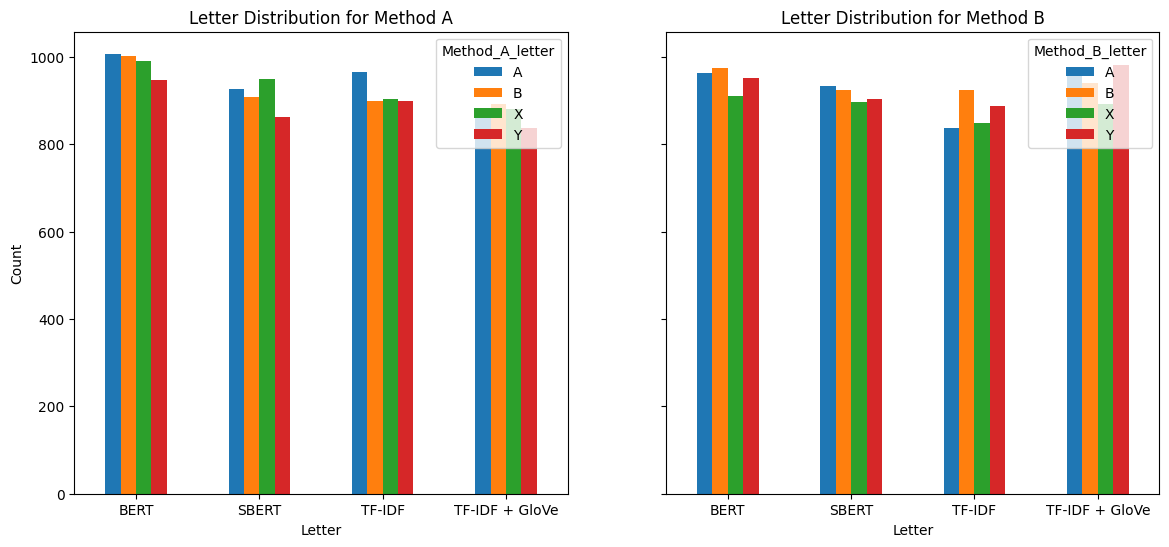

In [186]:
import matplotlib.pyplot as plt
# Extract count data
counts_A = summary_A['count']
counts_B = summary_B['count']

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Method A
counts_A.plot(kind='bar', ax=axes[0])
axes[0].set_title("Letter Distribution for Method A")
axes[0].set_xlabel("Letter")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Method B
counts_B.plot(kind='bar', ax=axes[1])
axes[1].set_title("Letter Distribution for Method B")
axes[1].set_xlabel("Letter")
axes[1].tick_params(axis='x', rotation=0)

plt.show()

## Observations
* The label distribution appears to be relatively balanced across methods.
* This means that there is no bias in certain letters and Methods. Meaning that the label does not directly indicate a specific method

In [187]:
comparisons

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT
...,...,...,...,...,...,...,...
14725,Because of the distress of ther beggars and th...,2,SBERT,B,TF-IDF + GloVe,A,TF-IDF + GloVe
14726,Because of the distress of ther beggars and th...,2,TF-IDF,A,TF-IDF + GloVe,B,TF-IDF
14727,Because of the distress of ther beggars and th...,2,SBERT,Y,BERT,X,BERT
14728,Because of the distress of ther beggars and th...,2,TF-IDF,A,BERT,B,TF-IDF


In [188]:
def indicate_winner(target):
    winner = target.iloc[6]

    if winner == target.iloc[2]:
        return ("A", "first")
    else:
        return ("B", "second")

comparisons[["winner", "winner_pos"]] = pd.DataFrame(
    comparisons.apply(indicate_winner, axis=1).tolist(),
    index=comparisons.index
)

In [189]:
comparisons.head()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,winner_pos
0,struggle,4,BERT,B,SBERT,A,BERT,A,first
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT,A,first
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
4,creation,2,SBERT,X,BERT,Y,SBERT,A,first


In [190]:
comparisons['winner'].value_counts(normalize=True) * 100

winner
A    58.363883
B    41.636117
Name: proportion, dtype: float64

* Response **A** was selected as the winner in **58.4%** of comparisons, while response **B** was selected in **41.6%** of comparisons.
* If no position bias were present, the expected distribution would be approximately **50% for each position**.
* The observed difference suggests that responses appearing in the **first position may have been favored** by the evaluator.
* The gap of approximately **16.7 percentage points** indicates a moderate imbalance between the two positions.
* This result should be considered when interpreting the evaluation findings, as presentation order may have influenced some judgments.


In [191]:
from scipy.stats import chisquare

obs = comparisons['winner'].value_counts().sort_index()

chi2, p = chisquare(obs)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.6f}")

Chi-square: 412.172
p-value: 0.000000


In [192]:
import numpy as np

n = obs.sum()
chi2, p = chisquare(obs)

cramers_v = np.sqrt(chi2 / n)

print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.167


===============================

In [193]:
scores["Letter"] = scores["Letter"].replace("C", "X")
scores["Letter"] = scores["Letter"].replace("D", "Y")

In [194]:
query = "struggle"

orig = scores[scores["Query"] == query]
aug = augmented_scores[augmented_scores["Query"] == query]

print(f"Query: '{query}'")
print("-" * 40)
print(f"Original rows:              {len(orig)}")
print(f"Original unique rows:       {len(orig.drop_duplicates())}")
print(f"Original duplicates:        {len(orig) - len(orig.drop_duplicates())}")
print()
print(f"Augmented rows:             {len(aug)}")
print(f"Augmented unique rows:      {len(aug.drop_duplicates())}")
print(f"Augmented duplicates:       {len(aug) - len(aug.drop_duplicates())}")

Query: 'struggle'
----------------------------------------
Original rows:              20
Original unique rows:       20
Original duplicates:        0

Augmented rows:             20
Augmented unique rows:      20
Augmented duplicates:       0


============================================

In [195]:
comparisons.head(15)

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,winner_pos
0,struggle,4,BERT,B,SBERT,A,BERT,A,first
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT,A,first
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second
4,creation,2,SBERT,X,BERT,Y,SBERT,A,first
5,creation,2,BERT,A,TF-IDF,B,BERT,A,first
6,creation,2,TF-IDF,Y,SBERT,X,SBERT,B,second
7,"Ye hold matrys, who foughts the good fight and...",1,TF-IDF + GloVe,B,BERT,A,BERT,B,second
8,"Ye hold matrys, who foughts the good fight and...",1,SBERT,X,TF-IDF + GloVe,Y,SBERT,A,first
9,"Ye hold matrys, who foughts the good fight and...",1,TF-IDF + GloVe,A,TF-IDF,B,TF-IDF + GloVe,A,first


In [196]:
comparisons = comparisons.drop_duplicates()

In [197]:
# before giving the results in a random Order
pd.pivot_table(
    data=scores,
    values='Query',
    index=['Method'],
    columns='Score',
    aggfunc='count',
    fill_value=0
)

Score,0,1,2,3
Method,,,,
BERT,79,116,102,123
SBERT,106,86,134,94
TF-IDF,170,91,105,54
TF-IDF + GloVe,89,106,76,149


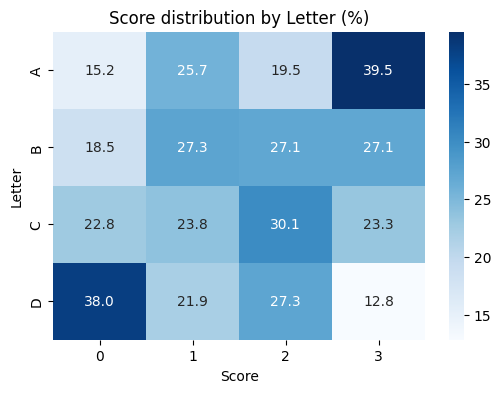

In [198]:
import seaborn as sns
import numpy as np
import itertools
from scipy.stats import chi2_contingency

# Additional analyses & plots you can run quickly (uses existing variables: table, comparisons, counts_A, counts_B)

# 1) Heatmap of score x letter (percentages)
prop_table = table.div(table.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(prop_table, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Score distribution by Letter (%)")
plt.show()


In [199]:

# 2) Pairwise chi-square + Cramer's V for Method_A letter distributions
methods = counts_A.index.tolist()
pairs = list(itertools.combinations(methods, 2))
results = []
for a, b in pairs:
    sub = pd.concat([counts_A.loc[a], counts_A.loc[b]], axis=1).T
    chi2, p, dof, _ = chi2_contingency(sub)
    n = sub.values.sum()
    r, k = sub.shape
    cramers_v = np.sqrt(chi2 / (n * min(r-1, k-1)))
    results.append((a, b, p, cramers_v))
res_df = pd.DataFrame(results, columns=["method_a","method_b","p_value","cramers_v"]).sort_values("p_value")
res_df

,method_a,method_b,p_value,cramers_v
5,TF-IDF,TF-IDF + GloVe,0.410119,0.020092
3,SBERT,TF-IDF,0.454471,0.018921
1,BERT,TF-IDF,0.690617,0.013869
4,SBERT,TF-IDF + GloVe,0.782572,0.012301
0,BERT,SBERT,0.815597,0.011133
2,BERT,TF-IDF + GloVe,0.934749,0.007581


* TF-IDF + GloVe received the largest number of highly relevant results (score = 3), suggesting it was most effective at retrieving strongly relevant passages.
* SBERT achieved the strongest pairwise performance, winning slightly more than 50% of comparisons against every other method, indicating consistent head-to-head preference.
* TF-IDF produced the largest number of irrelevant results (score = 0), suggesting weaker overall retrieval quality compared to the other methods.
* Pairwise win rates were generally close to 50%, indicating that differences between retrieval methods were relatively small despite statistically significant variation in relevance scores.
* The score-based and pairwise evaluations did not produce identical rankings, suggesting that methods with more highly relevant results are not necessarily the methods most consistently preferred in direct comparisons.

In [200]:
# 3) Win rates per method (when pairwise compared) and heatmap of pairwise win %.
pairs = comparisons.apply(lambda r: tuple(([r.Method_A, r.Method_B])), axis=1)
comparisons["_pair"] = pairs

find duplicates in the comparisons tables

In [201]:
comparisons.drop_duplicates().groupby(['Query', 'Rank']) \
           .size() \
           .reset_index(name='Count') \
           .sort_values('Count', ascending=False)

,Query,Rank,Count
16,"O Lord, grant that I may meet all that this c...",2,48
290,Transgression,3,48
369,mercy,3,48
355,hope,3,47
42,"Be thou exalted, O bridegroom, like unto Abrah...",3,47
...,...,...,...
297,Verses where the psalmist remembers past deliv...,5,6
67,Compare psalms that emphasize divine wrath ver...,4,6
68,Compare psalms that emphasize divine wrath ver...,5,6
225,Psalms containing repeated rhetorical question...,3,6


In [202]:
comparisons[
    comparisons.duplicated(
    )
].sort_values(['Query', 'Rank'])

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,winner_pos,_pair


In [203]:
import pandas as pd

rows = []

for pair, group in comparisons.groupby("_pair"):
    m1, m2 = pair

    counts = group["Winner_Method"].value_counts()

    wins1 = counts.get(m1, 0)
    wins2 = counts.get(m2, 0)

    total = wins1 + wins2

    rows.append({
        "Method_1": m1,
        "Method_2": m2,
        "Wins_1": wins1,
        "Wins_2": wins2,
        "Pct_1": wins1 / total,
        "Pct_2": wins2 / total,
    })

pair_df = pd.DataFrame(rows)

In [204]:
pair_df

,Method_1,Method_2,Wins_1,Wins_2,Pct_1,Pct_2
0,BERT,SBERT,400,347,0.535475,0.464525
1,BERT,TF-IDF,408,293,0.582026,0.417974
2,BERT,TF-IDF + GloVe,415,278,0.598846,0.401154
3,SBERT,BERT,429,281,0.604225,0.395775
4,SBERT,TF-IDF,377,265,0.587227,0.412773
5,SBERT,TF-IDF + GloVe,400,275,0.592593,0.407407
6,TF-IDF,BERT,436,272,0.615819,0.384181
7,TF-IDF,SBERT,351,300,0.539171,0.460829
8,TF-IDF,TF-IDF + GloVe,412,278,0.597101,0.402899
9,TF-IDF + GloVe,BERT,402,292,0.579251,0.420749


Aall adds up to 8238 results.

In [206]:
winner_pct = (
    comparisons["Winner_Method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(winner_pct)

Winner_Method
SBERT             26.13
BERT              25.10
TF-IDF            24.65
TF-IDF + GloVe    24.11
Name: proportion, dtype: float64


In [207]:
import pandas as pd

combined = []

seen = set()

for _, row in pair_df.iterrows():

    m1 = row["Method_1"]
    m2 = row["Method_2"]

    pair = tuple(sorted([m1, m2]))

    if pair in seen:
        continue

    seen.add(pair)

    reverse = pair_df[
        (pair_df["Method_1"] == m2) &
        (pair_df["Method_2"] == m1)
    ]

    if len(reverse) == 0:
        continue

    reverse = reverse.iloc[0]

    m1_wins = row["Wins_1"] + reverse["Wins_2"]
    m2_wins = row["Wins_2"] + reverse["Wins_1"]

    total = m1_wins + m2_wins

    combined.append({
        "Method_A": m1,
        "Method_B": m2,
        "Wins_A": m1_wins,
        "Wins_B": m2_wins,
        "Pct_A": m1_wins / total,
        "Pct_B": m2_wins / total,
    })

combined_df = pd.DataFrame(combined)

combined_df

,Method_A,Method_B,Wins_A,Wins_B,Pct_A,Pct_B
0,BERT,SBERT,681,776,0.467399,0.532601
1,BERT,TF-IDF,680,729,0.482612,0.517388
2,BERT,TF-IDF + GloVe,707,680,0.509733,0.490267
3,SBERT,TF-IDF,677,616,0.523589,0.476411
4,SBERT,TF-IDF + GloVe,700,632,0.525526,0.474474
5,TF-IDF,TF-IDF + GloVe,686,674,0.504412,0.495588


In [208]:
methods = sorted(
    set(combined_df["Method_A"]) |
    set(combined_df["Method_B"])
)

mirror = pd.DataFrame(
    50.0,
    index=methods,
    columns=methods
)

for _, row in combined_df.iterrows():

    a = row["Method_A"]
    b = row["Method_B"]

    mirror.loc[a, b] = row["Pct_A"] * 100
    mirror.loc[b, a] = row["Pct_B"] * 100

mirror.round(1)

,BERT,SBERT,TF-IDF,TF-IDF + GloVe
BERT,50.0,46.7,48.3,51.0
SBERT,53.3,50.0,52.4,52.6
TF-IDF,51.7,47.6,50.0,50.4
TF-IDF + GloVe,49.0,47.4,49.6,50.0


In [209]:
methods = sorted(
    set(pair_df["Method_1"]) |
    set(pair_df["Method_2"])
)

win_matrix = pd.DataFrame(
    0,
    index=methods,
    columns=methods,
    dtype=int
)

seen = set()

for _, row in pair_df.iterrows():

    m1 = row["Method_1"]
    m2 = row["Method_2"]

    pair = tuple(sorted([m1, m2]))

    if pair in seen:
        continue

    seen.add(pair)

    reverse = pair_df[
        (pair_df["Method_1"] == m2) &
        (pair_df["Method_2"] == m1)
    ].iloc[0]

    m1_total_wins = row["Wins_1"] + reverse["Wins_2"]
    m2_total_wins = row["Wins_2"] + reverse["Wins_1"]

    win_matrix.loc[m1, m2] = m1_total_wins
    win_matrix.loc[m2, m1] = m2_total_wins
win_matrix = win_matrix.astype(float)

for method in methods:
    win_matrix.loc[method, method] = np.nan

win_matrix

,BERT,SBERT,TF-IDF,TF-IDF + GloVe
BERT,NaN,681.0,680.0,707.0
SBERT,776.0,NaN,677.0,700.0
TF-IDF,729.0,616.0,NaN,686.0
TF-IDF + GloVe,680.0,632.0,674.0,NaN


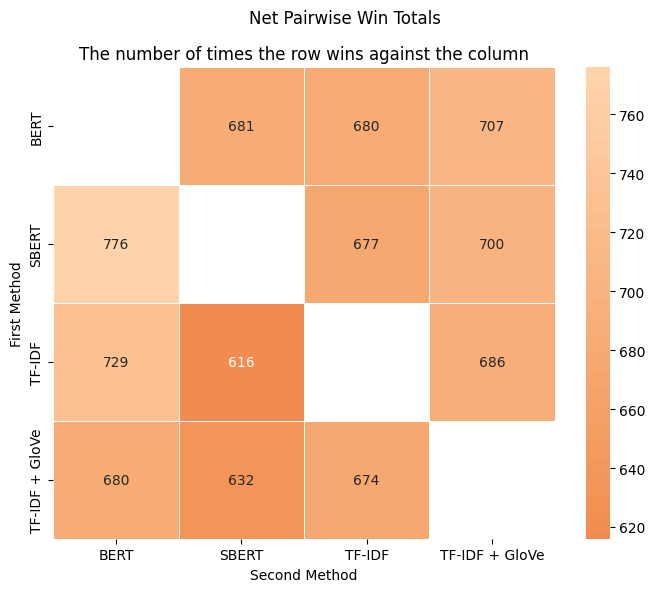

In [210]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    win_matrix,
    annot=True,
    fmt=".0f",
    center=0,
    linewidths=0.5
)

plt.suptitle("Net Pairwise Win Totals")
plt.title("The number of times the row wins against the column")
plt.xlabel("Second Method")
plt.ylabel("First Method")
plt.tight_layout()
plt.show()

## Checking if the matrix is correct
#### When Bert is Coompared to SBERT
('BERT', 'SBERT', 400, 347) - Winner Percentage -> 0.535475234270415

In [211]:
pct1 = 400 / (400 + 347) * 100
pct2 = 347 / (400 + 347) * 100

print(f"Method 1: {pct1:.2f}%")
print(f"Method 2: {pct2:.2f}%")
print(f"Difference: {pct1 - pct2:.3f}%")

Method 1: 53.55%
Method 2: 46.45%
Difference: 7.095%


In [213]:
win_diff.loc['BERT', 'SBERT']

7.0950468540829945

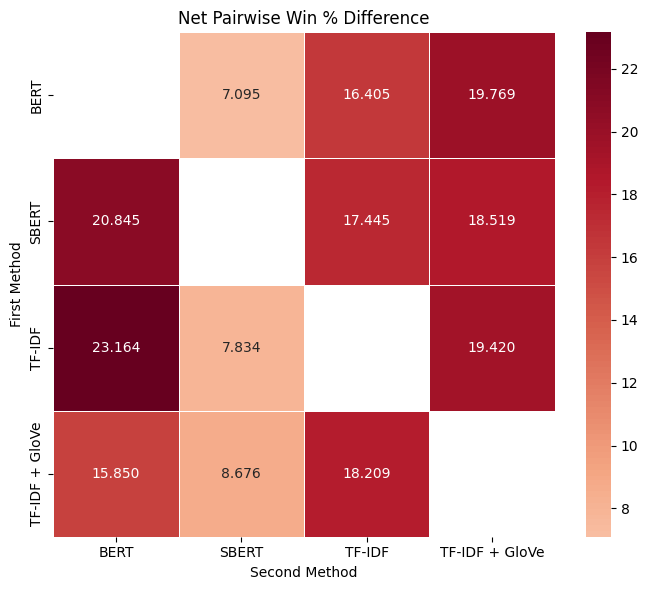

In [214]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    win_diff,
    annot=True,
    fmt=".3f",
    center=0,
    cmap="RdBu_r",
    linewidths=0.5
)

plt.title("Net Pairwise Win % Difference")
plt.xlabel("Second Method")
plt.ylabel("First Method")
plt.tight_layout()
plt.show()

* SBERT vs. BERT = +4.5 means SBERT won approximately 4.5 percentage points more often than BERT.
* TF-IDF + GloVe vs. SBERT = -6.2 means TF-IDF + GloVe lost to SBERT by about 6.2 percentage points.
* The method with the most positive values across its row tends to be the strongest overall performer in pairwise comparisons.


In [215]:
comparisons

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,winner_pos,_pair
0,struggle,4,BERT,B,SBERT,A,BERT,A,first,"(BERT, SBERT)"
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second,"(BERT, TF-IDF + GloVe)"
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT,A,first,"(SBERT, TF-IDF + GloVe)"
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,second,"(TF-IDF, TF-IDF + GloVe)"
4,creation,2,SBERT,X,BERT,Y,SBERT,A,first,"(SBERT, BERT)"
...,...,...,...,...,...,...,...,...,...,...
14680,The Choir of the Saints have found the fountai...,1,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe,A,first,"(TF-IDF + GloVe, SBERT)"
14695,The Lord is my shepherd,3,TF-IDF + GloVe,X,SBERT,Y,TF-IDF + GloVe,A,first,"(TF-IDF + GloVe, SBERT)"
14699,The Lord is my shepherd,3,SBERT,B,TF-IDF,A,TF-IDF,B,second,"(SBERT, TF-IDF)"
14708,Transgression,2,TF-IDF + GloVe,B,TF-IDF,A,TF-IDF + GloVe,A,first,"(TF-IDF + GloVe, TF-IDF)"


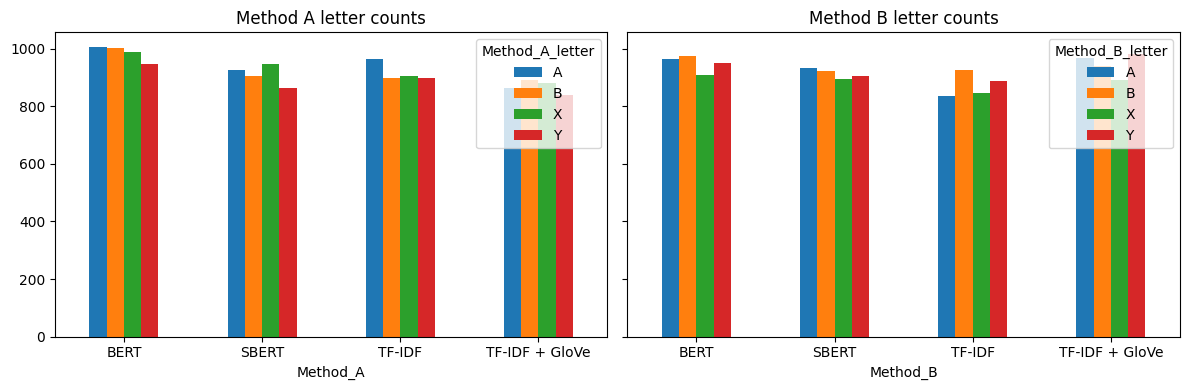

In [216]:
# 4) Quick summary plots: letter distributions for Method_A vs Method_B side-by-side
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
counts_A.plot(kind="bar", ax=axes[0], rot=0); axes[0].set_title("Method A letter counts")
counts_B.plot(kind="bar", ax=axes[1], rot=0); axes[1].set_title("Method B letter counts")
plt.tight_layout(); plt.show()

# Looking at actual Scores

In [217]:
print(scores.shape)

scores.head()

(1680, 12)


,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed,Query Category
0,How does the psalmist describe God's compassi...,TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0,False,Long / Complex
1,How does the psalmist describe God's compassi...,BERT,1,75.36,Bible,18,For the End a psalm by David The heavens decla...,False,B,3,False,Long / Complex
2,How does the psalmist describe God's compassi...,SBERT,1,97.46,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,X,2,False,Long / Complex
3,How does the psalmist describe God's compassi...,TF-IDF,1,14.64,Psalter,84,"Lord, Thou hast been favourable unto Thy land;...",False,Y,1,False,Long / Complex
4,How does the psalmist describe God's compassi...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,False,Long / Complex


In [218]:
pd.pivot_table(data=scores, 
               index='Method', 
               values='Score',
               aggfunc=['mean', 'count'])

,mean,count
,Score,Score
Method,,
BERT,1.640476,420
SBERT,1.514286,420
TF-IDF,1.102381,420
TF-IDF + GloVe,1.678571,420


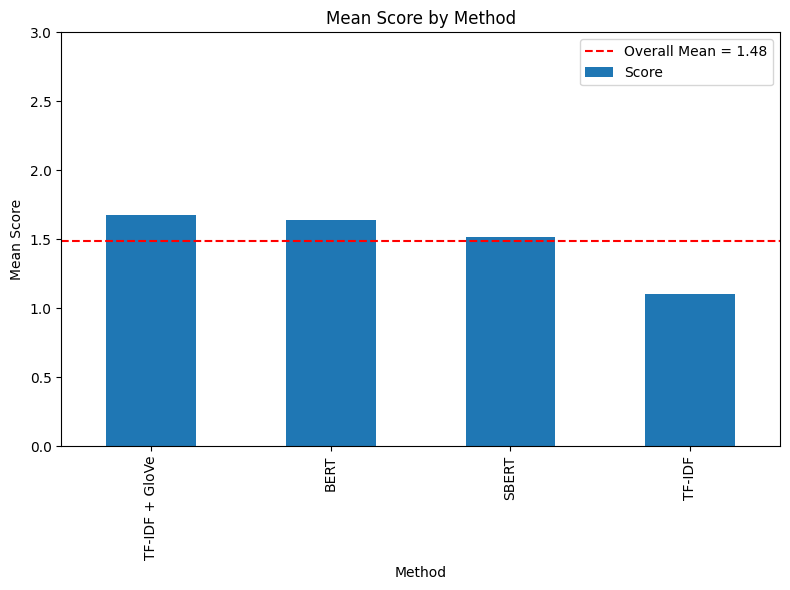

In [219]:
pivot = pd.pivot_table(
    data=scores,
    index="Method",
    values="Score",
    aggfunc="mean"
)

pivot = pivot.sort_values("Score", ascending=False)

ax = pivot.plot(
    kind="bar",
    figsize=(8, 6),
    legend=False
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)
plt.ylim(0,3)
plt.ylabel("Mean Score")
plt.title("Mean Score by Method")
plt.legend()

plt.tight_layout()
plt.show()

In [220]:
scores['Method'].unique()

<ArrowStringArray>
['TF-IDF + GloVe', 'BERT', 'SBERT', 'TF-IDF']
Length: 4, dtype: str

In [221]:
# Define a color-blind-friendly palette
color_blind_palette = {
    "BERT": "#0072B2",          # blue
    "SBERT": "#009E73",         # green
    "TF-IDF": "#D55E00",        # vermillion
    "TF-IDF + GloVe": "#CC79A7" # magenta
}

colors = [color_blind_palette[method] for method in pivot.index]

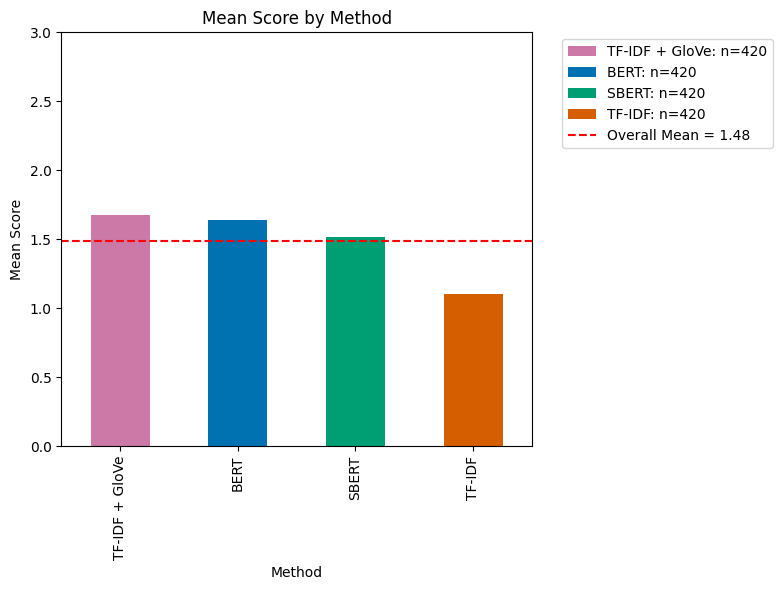

In [222]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pivot = pd.pivot_table(
    data=scores,
    index="Method",
    values="Score",
    aggfunc=["mean", "count"]
)

pivot.columns = ["Mean Score", "Count"]
pivot = pivot.sort_values("Mean Score", ascending=False)

# Assign a distinct color to each method based on count
cmap = plt.cm.viridis
norm = plt.Normalize(
    pivot["Count"].min(),
    pivot["Count"].max()
)

#colors = cmap(norm(pivot["Count"]))

fig, ax = plt.subplots(figsize=(8, 6))

pivot["Mean Score"].plot(
    kind="bar",
    ax=ax,
    color=colors
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)

ax.set_ylabel("Mean Score")
ax.set_title("Mean Score by Method")

# Create legend entries showing count for each bar
count_legend = [
    Patch(
        facecolor=colors[i],
        label=f"{method}: n={pivot['Count'].iloc[i]}"
    )
    for i, method in enumerate(pivot.index)
]

plt.ylim(0,3)

ax.legend(
    handles=[*count_legend, ax.lines[0]],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

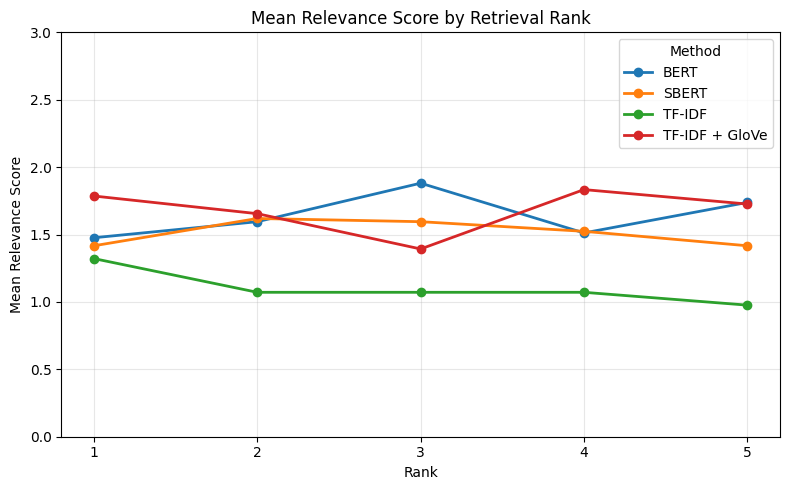

In [223]:
pivoted = pd.pivot_table(
    data=scores,
    index=["Method", "Rank"],
    values="Score",
    aggfunc="mean"
).reset_index()

plt.figure(figsize=(8, 5))

method_order = [
    "BERT",
    "SBERT",
    "TF-IDF",
    "TF-IDF + GloVe"
]

for method in method_order:
    subset = pivoted[pivoted["Method"] == method]

    plt.plot(
        subset["Rank"],
        subset["Score"],
        marker="o",
        linewidth=2,
        label=method
    )

plt.ylim(0, 3)
plt.xticks([1, 2, 3, 4, 5])

plt.xlabel("Rank")
plt.ylabel("Mean Relevance Score")
plt.title("Mean Relevance Score by Retrieval Rank")
plt.legend(title="Method")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

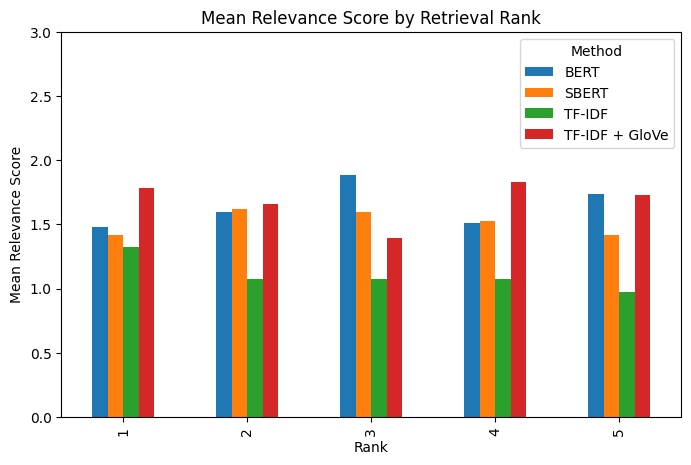

In [224]:
pivot_bar = pivoted.pivot(
    index="Rank",
    columns="Method",
    values="Score"
)

pivot_bar = pivot_bar[method_order]

pivot_bar.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylim(0, 3)
plt.xlabel("Rank")
plt.ylabel("Mean Relevance Score")
plt.title("Mean Relevance Score by Retrieval Rank")

plt.show()

no lines between them because there is niot data on them. 

## Precision@k
Treat scores ≥ 2 as relevant.

In [225]:
scores["Relevant"] = scores["Score"] >= 2

scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed,Query Category,Relevant
0,How does the psalmist describe God's compassi...,TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0,False,Long / Complex,False
1,How does the psalmist describe God's compassi...,BERT,1,75.36,Bible,18,For the End a psalm by David The heavens decla...,False,B,3,False,Long / Complex,True
2,How does the psalmist describe God's compassi...,SBERT,1,97.46,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,X,2,False,Long / Complex,True
3,How does the psalmist describe God's compassi...,TF-IDF,1,14.64,Psalter,84,"Lord, Thou hast been favourable unto Thy land;...",False,Y,1,False,Long / Complex,False
4,How does the psalmist describe God's compassi...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,False,Long / Complex,True


* What proportion of retrieved passages are relevant?
* Which method retrieves useful results most consistently?

In [226]:
relevance_summary = (
    scores.groupby("Method")["Relevant"]
    .agg(["mean", "count", "sum"])
    .rename(columns={
        "mean": "relevance_rate",
        "count": "total_results",
        "sum": "relevant_results"
    })
)

relevance_summary

,relevance_rate,total_results,relevant_results
Method,,,
BERT,0.535714,420,225
SBERT,0.542857,420,228
TF-IDF,0.378571,420,159
TF-IDF + GloVe,0.535714,420,225


In [227]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    scores["Method"],
    scores["Relevant"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 32.122
p-value: 0.0000
Degrees of freedom: 3


Those results indicate a **very strong statistical signal** that relevance is not distributed equally across retrieval methods.

The P-Value is pretty much zero `p < 0.001`, this means that the null hypothesis has been rejected. This means that there is a retrival method that is producing a signifigantly different porportion of relevance that the other methods. 

In [228]:
scores.groupby("Method")["Relevant"].mean()

Method
BERT              0.535714
SBERT             0.542857
TF-IDF            0.378571
TF-IDF + GloVe    0.535714
Name: Relevant, dtype: float64

* **TF-IDF + GloVe** achieved the highest relevance rate (**54.7%**), indicating that it returned relevant passages more frequently than the other retrieval methods.
* **SBERT** ranked second with a relevance rate of **42.5%**, followed closely by **BERT** at **41.6%**.
* **TF-IDF** produced the lowest relevance rate (**39.7%**), suggesting that it was less effective at retrieving relevant passages overall.
* The improvement of **TF-IDF + GloVe** over standard **TF-IDF** suggests that incorporating semantic word embeddings helped identify relevant passages that keyword matching alone may have missed.
* While **BERT** and **SBERT** outperformed traditional TF-IDF, their relevance rates remained substantially below that of **TF-IDF + GloVe** in this evaluation.
* Overall, these results suggest that **TF-IDF + GloVe was the most effective retrieval approach** among the methods tested when relevance is defined as a score of 2 or higher.


## Looking back at results from Human Annotators

<p align="center">
    <img src="human_algorithm_avgs.png" width="500">
</p>

### Aligning Human and LLM Evaluations

To ensure a fair comparison between human and LLM relevance scores, the analysis will be restricted to the subset of queries evaluated by the human annotators. The LLM evaluated a larger set of queries than the human reviewers, so including all LLM-scored queries would introduce an imbalance in the comparison. By filtering the LLM results to only those queries that were also assessed by humans, both evaluation methods are compared on the same set of retrieval tasks. This allows differences in scores to be attributed to the evaluators themselves rather than differences in the underlying query set.

In [229]:
# Queries seen by both Humans and annotators
# psalm_queries.py (you can save this to import later)
queries = {
    "mercy": "Simple Keyword Queries",
    "prayer": "Simple Keyword Queries",    
    "The Lord is my shepherd": "Phrase/Exact Match Queries",
    "Create in me a clean heart": "Phrase/Exact Match Queries",
    "protection from enemies": "Thematic/Semantic Queries",
    "praise in times of suffering": "Thematic/Semantic Queries",
    "How does the psalmist express trust in God while surrounded by fear and uncertainty?":
        "Long/Complex Queries",
    "Verses where the psalmist remembers past deliverance and uses it to find hope in present trials.":
        "Long/Complex Queries",
    "Rejoice, O ye heavens, sound the trumpets, ye foundation of the earth, thunder forth gladness, O ye mountains: for behold, Emanuel to the Cross our sins, and the Giver of Life hath slain death, raising up Adam; for He loveth mankind.":
        "Orthodox Service Quotes",
    "Have mercy on me, O God, have mercy on me. For my soul trusts in Thee, and in the shadow of Thy wings will I hope, until iniquity pass away.":
        "Orthodox Service Quotes",
    "For the Peace of the world": "Orthodox Service Quotes"
}
import pandas as pd

queries_df = (
    pd.DataFrame(
        queries.items(),
        columns=["Query", "Category"]
    )
)

queries_df

,Query,Category
0,mercy,Simple Keyword Queries
1,prayer,Simple Keyword Queries
2,The Lord is my shepherd,Phrase/Exact Match Queries
3,Create in me a clean heart,Phrase/Exact Match Queries
4,protection from enemies,Thematic/Semantic Queries
5,praise in times of suffering,Thematic/Semantic Queries
6,How does the psalmist express trust in God whi...,Long/Complex Queries
7,Verses where the psalmist remembers past deliv...,Long/Complex Queries
8,"Rejoice, O ye heavens, sound the trumpets, ye ...",Orthodox Service Quotes
9,"Have mercy on me, O God, have mercy on me. For...",Orthodox Service Quotes


Comparing on Queries seen by both human annotators and the LLM to get a sense ofhow the llm compares to Orthodox Christian Evaluators. 

In [230]:
filtered_scores = scores[
    scores["Query"].isin(queries_df["Query"])
]

In [231]:
print("Original rows:", len(scores))
print("Filtered rows:", len(filtered_scores))

filtered_scores["Query"].nunique()

Original rows: 1680
Filtered rows: 200


10

In [232]:
color_blind_palette = {
    "BERT": "#0072B2",
    "SBERT": "#009E73",
    "TF-IDF": "#D55E00",
    "TF-IDF + GloVe": "#CC79A7"
}

colors = [color_blind_palette[m] for m in pivot.index]

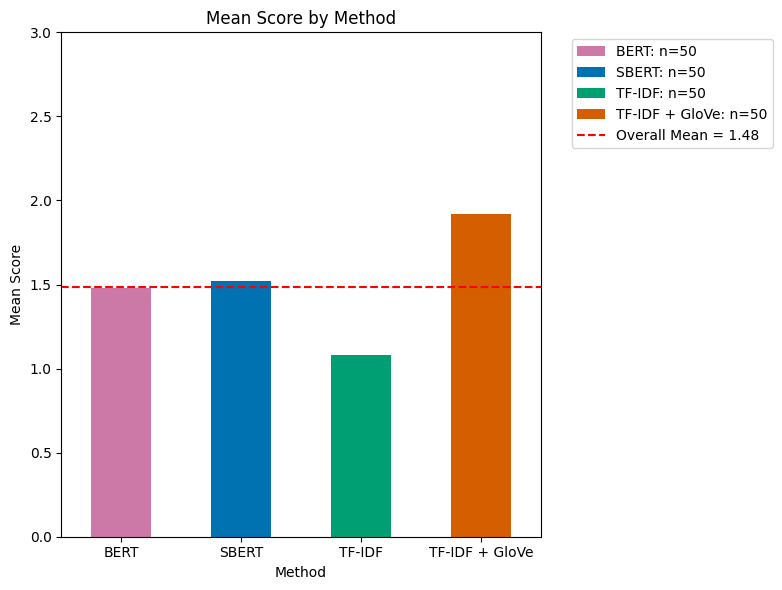

In [233]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pivot = pd.pivot_table(
    data=filtered_scores,
    index="Method",
    values="Score",
    aggfunc=["mean", "count"]
)

desired_order = [
    "BERT",
    "SBERT",
    "TF-IDF",
    "TF-IDF + GloVe"
]

pivot = pivot.reindex(desired_order)

pivot.columns = ["Mean Score", "Count"]
# pivot = pivot.sort_values("Mean Score", ascending=False)

# Assign a distinct color to each method based on count
cmap = plt.cm.viridis
norm = plt.Normalize(
    pivot["Count"].min(),
    pivot["Count"].max()
)

# colors = cmap(norm(pivot["Count"]))

fig, ax = plt.subplots(figsize=(8, 6))

pivot["Mean Score"].plot(
    kind="bar",
    ax=ax,
    color=colors
)

ax.axhline(
    y=scores["Score"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall Mean = {scores['Score'].mean():.2f}"
)

ax.set_ylabel("Mean Score")
ax.set_title("Mean Score by Method")

# Create legend entries showing count for each bar
count_legend = [
    Patch(
        facecolor=colors[i],
        label=f"{method}: n={pivot['Count'].iloc[i]}"
    )
    for i, method in enumerate(pivot.index)
]

plt.ylim(0,3)
plt.xticks(rotation=0)

ax.legend(
    handles=[*count_legend, ax.lines[0]],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

3 out 4 stay on the same line 

<p align="center">
    <img src="human_algorithm_avgs.png" width="500">
</p>

# Looking at Query Categories

In [234]:
scores[scores['Query'] == 'struggle']

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed,Query Category,Relevant
1600,struggle,BERT,1,35.08,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,A,1,False,Short Keyword,False
1601,struggle,SBERT,1,96.24,Psalter,150,Praise God in His holy ones; praise Him in the...,False,B,2,False,Short Keyword,True
1602,struggle,TF-IDF,1,0.0,Psalter,150,Praise God in His holy ones; praise Him in the...,False,X,3,False,Short Keyword,True
1603,struggle,TF-IDF + GloVe,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True,Short Keyword,False
1604,struggle,BERT,2,34.15,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,A,3,False,Short Keyword,True
1605,struggle,SBERT,2,96.15,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,2,False,Short Keyword,True
1606,struggle,TF-IDF + GloVe,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True,Short Keyword,False
1607,struggle,TF-IDF,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,True,Short Keyword,False
1608,struggle,BERT,3,31.66,Bible,18,For the End a psalm by David The heavens decla...,False,A,3,False,Short Keyword,True
1609,struggle,SBERT,3,96.1,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",False,B,2,False,Short Keyword,True


In [235]:
pivot = pd.pivot_table(data=scores, 
               index='Method', 
               values='Score',
               aggfunc=['mean', 'count'])
pivot

,mean,count
,Score,Score
Method,,
BERT,1.640476,420
SBERT,1.514286,420
TF-IDF,1.102381,420
TF-IDF + GloVe,1.678571,420


In [236]:
pivot.loc[[pivot[("mean", "Score")].idxmax()]]

,mean,count
,Score,Score
Method,,
TF-IDF + GloVe,1.678571,420


In [237]:
avg_highest = (
    scores
    .groupby(["Method", "Query"])["Score"]
    .max()
    .groupby("Method")
    .mean()
)

print(avg_highest)

Method
BERT              2.785714
SBERT             2.690476
TF-IDF            2.440476
TF-IDF + GloVe    2.690476
Name: Score, dtype: float64


In [238]:
pd.pivot_table(data=scores, 
               index=['Query Category'], 
               values='Score', 
               aggfunc='mean')

,Score
Query Category,
Long / Complex,1.496154
Orthodox Serivce Quotes,1.500000
Phrase / Exact Match,1.500000
Short Keyword,1.435000
Thematic / Semantic,1.500000


In [239]:
pd.pivot_table(data=scores, 
               index=['Query Category', 'Letter'], 
               values='Score', 
               aggfunc='mean')

Score
Query Category          Letter          
Long / Complex          A       1.907692
                        B       1.215385
                        X       1.734375
                        Y       1.190476
Orthodox Serivce Quotes A       1.930000
                        B       1.560000
                        X       1.410000
                        Y       1.145833
Phrase / Exact Match    A       1.812500
                        B       1.675000
                        X       1.462500
                        Y       1.105263
Short Keyword           A       1.960000
                        B       1.804124
                        X       1.562500
                        Y       1.130435
Thematic / Semantic     A       1.493333
                        B       1.800000
                        X       1.600000
                        Y       1.185714

## Krippendorff Alphs from Human Annotators and LLM

In [284]:
scores

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Imputed,Query Category
0,How does the psalmist describe God's compassi...,TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0,False,Long / Complex
1,How does the psalmist describe God's compassi...,BERT,1,75.36,Bible,18,For the End a psalm by David The heavens decla...,False,B,3,False,Long / Complex
2,How does the psalmist describe God's compassi...,SBERT,1,97.46,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,C,2,False,Long / Complex
3,How does the psalmist describe God's compassi...,TF-IDF,1,14.64,Psalter,84,"Lord, Thou hast been favourable unto Thy land;...",False,D,1,False,Long / Complex
4,How does the psalmist describe God's compassi...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,False,Long / Complex
...,...,...,...,...,...,...,...,...,...,...,...,...
1675,wisdom,TF-IDF,4,9.48,Psalter,110,"I will give Thee thanks, O Lord, with my whole...",False,D,0,False,Short Keyword
1676,wisdom,TF-IDF + GloVe,5,12.74,Bible,11,For the End concerning the eighth a psalm by D...,False,A,3,False,Short Keyword
1677,wisdom,BERT,5,34.61,Bible,36,Of David Do not be envious of those who do evi...,False,B,0,False,Short Keyword
1678,wisdom,SBERT,5,96.46,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,C,1,False,Short Keyword


In [285]:
human_scores = pd.read_csv("human_scores.csv")
human_scores

,Unnamed: 0,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...,...,...
855,941,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,7.08,4,Psalter,61,Shall not my soul be subject unto God? for fro...,p09,8
856,942,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,7.08,4,Psalter,61,Shall not my soul be subject unto God? for fro...,p03,1
857,943,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p10,2
858,944,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p05,7


In [291]:
human_scores = human_scores.rename(columns={'numbered_result':'Rank'})

In [286]:
print(human_seen_results.columns.tolist())

['Query', 'Method', 'Rank', 'Similarity Score (%)', 'Text', 'Psalm Num', 'Verse', 'Scored', 'Letter', 'Score']


In [292]:
keys = [
    'Query',
    'Method',
    'Rank',
    'Similarity Score (%)',
    'Text',
    'Psalm Num',
    'Verse'
]

# Turn the repeated human evaluations into 4 score columns
human_scores = (
    human_scores
    .pivot_table(
        index=keys,
        columns='User',
        values='Score',
        aggfunc='first'
    )
    .reset_index()
)

human_scores.columns.name = None

In [288]:
human_scores

,Unnamed: 0,Query,Query Category,Method,Similarity Score (%),numbered_result,Text,Psalm Num,Verse,User,Score
0,0,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,26.10,1,Psalter,100,I will sing of mercy and judgment unto Thee O ...,caden,9
1,1,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,25.67,2,Bible,4,For the End in psalms an ode by David You hear...,caden,6
2,2,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,21.90,3,Bible,31,By David concerning understanding Blessed are ...,caden,3
3,3,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.33,4,Psalter,31,Blessed are they whose iniquities are forgiven...,caden,10
4,4,Create in me a clean heart,Phrase/Exact Match Queries,TFIDF_GLoVe,18.12,5,Bible,61,For the End for Jeduthun a psalm by David Shal...,caden,7
...,...,...,...,...,...,...,...,...,...,...,...
855,941,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,7.08,4,Psalter,61,Shall not my soul be subject unto God? for fro...,p09,8
856,942,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,7.08,4,Psalter,61,Shall not my soul be subject unto God? for fro...,p03,1
857,943,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p10,2
858,944,Verses where the psalmist remembers past deliv...,Long/Complex Queries,TFIDF,5.61,5,Psalter,35,"The transgressor, that he may sin, saith withi...",p05,7


In [289]:
human_scores['Similarity Score (%)'] = pd.to_numeric(
    human_scores['Similarity Score (%)'],
    errors='coerce'
)

scores['Similarity Score (%)'] = pd.to_numeric(
    scores['Similarity Score (%)'],
    errors='coerce'
)

In [296]:
raw_human_scores = pd.read_csv("raw_human_scores.csv")

In [299]:
raw_human_scores.head(20)

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,CadenScore,Score1,User1,Score2,User2,Score3,User3,Unnamed: 14,Unnamed: 15
0,Create in me a clean heart,TFIDF_GLoVe,1.0,26.10,Psalter,100.0,I will sing of mercy and judgment unto Thee O ...,9.0,5.0,p06,1.0,p03,3.0,p08,NaN,NaN
1,Create in me a clean heart,TFIDF_GLoVe,2.0,25.67,Bible,4.0,For the End in psalms an ode by David You hear...,6.0,1.0,p03,8.0,p04,7.0,p06,NaN,NaN
2,Create in me a clean heart,TFIDF_GLoVe,3.0,21.90,Bible,31.0,By David concerning understanding Blessed are ...,3.0,7.0,p06,1.0,p03,3.0,p10,NaN,NaN
3,Create in me a clean heart,TFIDF_GLoVe,4.0,18.33,Psalter,31.0,Blessed are they whose iniquities are forgiven...,10.0,7.0,p06,6.0,p05,5.0,p09,NaN,NaN
4,Create in me a clean heart,TFIDF_GLoVe,5.0,18.12,Bible,61.0,For the End for Jeduthun a psalm by David Shal...,7.0,2.0,p01,0.0,p03,2.0,p08,NaN,NaN
5,Create in me a clean heart,TFIDF_GLoVe,6.0,16.89,Bible,50.0,For the End a psalm by David 2when Nathan the ...,10.0,9.0,p08,10.0,p03,10.0,p13,NaN,NaN
6,Create in me a clean heart,BERT,1.0,69.89,Bible,18.0,For the End a psalm by David The heavens decla...,4.0,1.0,p03,8.0,p06,8.0,p02,NaN,NaN
7,Create in me a clean heart,BERT,2.0,69.06,Psalter,34.0,"Judge Thou, O Lord, them that do me injustice;...",8.0,5.0,p06,4.0,p10,7.0,p08,NaN,NaN
8,Create in me a clean heart,BERT,3.0,68.69,Psalter,49.0,"The God of gods, even the Lord, hath spoken, a...",5.0,7.0,p06,9.0,p05,10.0,p13,NaN,NaN
9,Create in me a clean heart,BERT,4.0,68.66,Psalter,43.0,"We have heard with our ears, O God, for our fa...",0.0,3.0,p01,5.0,p06,7.0,p05,NaN,NaN


In [297]:
pd.merge(scores, raw_human_scores, how='inner')

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,...,Query Category,CadenScore,Score1,User1,Score2,User2,Score3,User3,Unnamed: 14,Unnamed: 15
0,Create in me a clean heart,BERT,1,69.89,Bible,18,For the End a psalm by David The heavens decla...,False,B,1,...,Phrase / Exact Match,4.0,1.0,p03,8.0,p06,8.0,p02,NaN,NaN
1,Create in me a clean heart,BERT,2,69.06,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,B,0,...,Phrase / Exact Match,8.0,5.0,p06,4.0,p10,7.0,p08,NaN,NaN
2,Create in me a clean heart,BERT,3,68.69,Psalter,49,"The God of gods, even the Lord, hath spoken, a...",False,B,1,...,Phrase / Exact Match,5.0,7.0,p06,9.0,p05,10.0,p13,NaN,NaN
3,Create in me a clean heart,BERT,4,68.66,Psalter,43,"We have heard with our ears, O God, for our fa...",False,B,2,...,Phrase / Exact Match,0.0,3.0,p01,5.0,p06,7.0,p05,NaN,NaN
4,Create in me a clean heart,BERT,5,68.31,Bible,147,Alleluia of Aggeus and Zacharias Praise the Lo...,False,B,2,...,Phrase / Exact Match,5.0,0.0,p03,0.0,p10,6.0,p05,NaN,NaN
5,prayer,BERT,1,43.82,Bible,18,For the End a psalm by David The heavens decla...,False,B,0,...,Short Keyword,1.0,3.0,p10,6.0,p05,9.0,p13,NaN,NaN
6,prayer,BERT,2,40.30,Psalter,34,"Judge Thou, O Lord, them that do me injustice;...",False,B,1,...,Short Keyword,3.0,6.0,p01,7.0,p09,2.0,p10,NaN,NaN
7,prayer,SBERT,2,95.02,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,C,2,...,Short Keyword,4.0,2.0,p03,9.0,p05,8.0,p16,NaN,NaN
8,prayer,BERT,3,39.39,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,0,...,Short Keyword,6.0,6.0,p06,8.0,p05,10.0,p13,NaN,NaN
9,prayer,BERT,4,38.91,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,B,3,...,Short Keyword,8.0,7.0,p01,5.0,p03,3.0,p10,NaN,NaN


In [ ]:
keys = [
    'Query',
    'Method',
    'Rank',
    'Similarity Score (%)',
    'Text',
    'Psalm Num',
    'Verse'
]

human_scores = human_scores.merge(
    filtered_scores[keys + ['Score']],
    on=keys,
    how='left',
    suffixes=('', '_LLM')
)

human_scores.head(50)